Epoch 1/20


C:\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5828 - loss: 1.5617 - val_accuracy: 0.7347 - val_loss: 0.9005
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7891 - loss: 0.7204 - val_accuracy: 0.8094 - val_loss: 0.6473
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8402 - loss: 0.5398 - val_accuracy: 0.8537 - val_loss: 0.5150
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8745 - loss: 0.4332 - val_accuracy: 0.8637 - val_loss: 0.4550
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8914 - loss: 0.3659 - val_accuracy: 0.8737 - val_loss: 0.4039
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9055 - loss: 0.3146 - val_accuracy: 0.8913 - val_loss: 0.3623
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9174 - loss: 0.2760 - val_accuracy: 0.8956 - val_loss: 0.3290
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9264 - loss: 0.2473 - val_accuracy: 0.8981 - val_

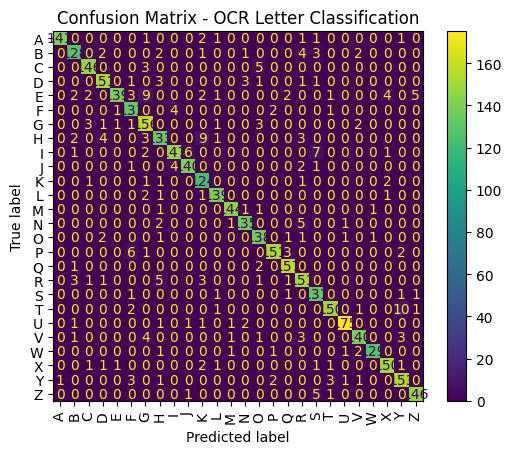

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# 1. Load dataset
dataset = pd.read_csv("letter-recognition.data", header=None)

# 2. Split features and labels
X = dataset.iloc[:, 1:17].values
y = dataset.iloc[:, 0].values

# 3. Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=10
)

# 5. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(16,)),
    Dense(64, activation='relu'),
    Dense(26, activation='softmax')
])

# 7. Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 8. Train
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# 9. Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

# -------------------------------------------------
# 🔥 VISIBLE OUTPUT PART (IMPORTANT)
# -------------------------------------------------

# 10. Predictions
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Convert numeric labels back to letters
predicted_letters = encoder.inverse_transform(predicted_labels)
true_letters = encoder.inverse_transform(true_labels)

# 11. Show sample predictions
print("\nSample Predictions:")
for i in range(10):
    print(f"Predicted: {predicted_letters[i]}  |  Actual: {true_letters[i]}")

# 12. Confusion Matrix (BEST VISUAL OUTPUT)
cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix - OCR Letter Classification")
plt.show()